# Koduppgift kapitel 6

## Uppgift 7

   median_income  latitude  longitude
0         8.3252     37.88    -122.23
1         8.3014     37.86    -122.22
2         7.2574     37.85    -122.24
3         5.6431     37.85    -122.25
4         3.8462     37.85    -122.25
   median_income  latitude  longitude Cluster
0         8.3252     37.88    -122.23       2
1         8.3014     37.86    -122.22       2
2         7.2574     37.85    -122.24       2
3         5.6431     37.85    -122.25       2
4         3.8462     37.85    -122.25       1


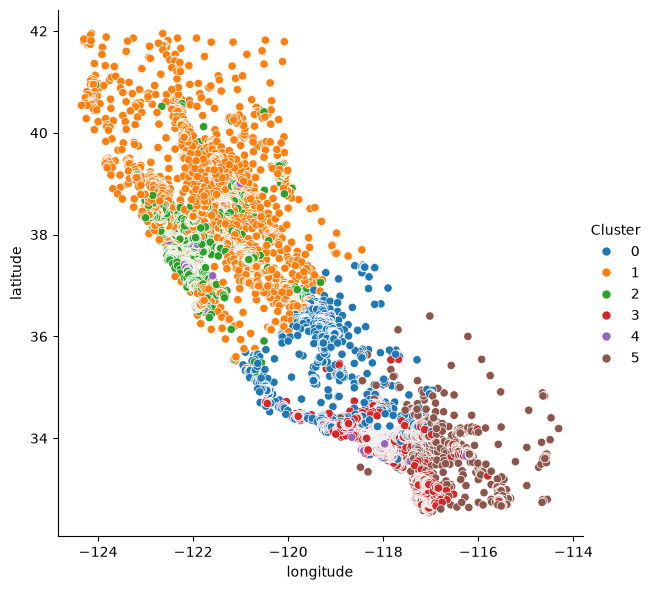

In [2]:
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns 
from sklearn.cluster import KMeans 

df = pd.read_csv("./dataset/housing.csv") 

X = df.loc[:, ["median_income", "latitude", "longitude"]] 
print(X.head()) 
kmeans = KMeans(n_clusters=6) 
X["Cluster"] = kmeans.fit_predict(X) 
X["Cluster"] = X["Cluster"].astype("category")

print(X.head())

sns.relplot(
    x='longitude', y='latitude', hue='Cluster', data=X, height=6
)


**A)** Det koden gör är att den läser in datasetet skapar vi en X med 3 kolumer i sig. vi kör sen en Kmean för att skapa en klustring med 6 st kluster i sig som vi kan jobba med. Vi tar sen och tränar X['cluster'] på datan, och sen renderar vi ut den.

**B)** Om jag bara utgår vad datasetet innehåller (s.70) så hade jag velat ha kluster som innehöll: total_rooms, total_rooms, median_house_value. Detta känns som det hade varit lättast om vi har vinklen om ätt vi sysslar med husförsäljning.

Då hade man även kunna lägga till hur långt man har till beach osv. 

och hade jag försökt sälja hus hade jag nog velat ha house prices med, men man kan inte få allt. med det är det jag hade velat göra kluster på. 

**C)**

känner att jag hade det resonemanget i B)

**D)**

In [3]:
df = pd.read_csv("./dataset/housing.csv") 

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


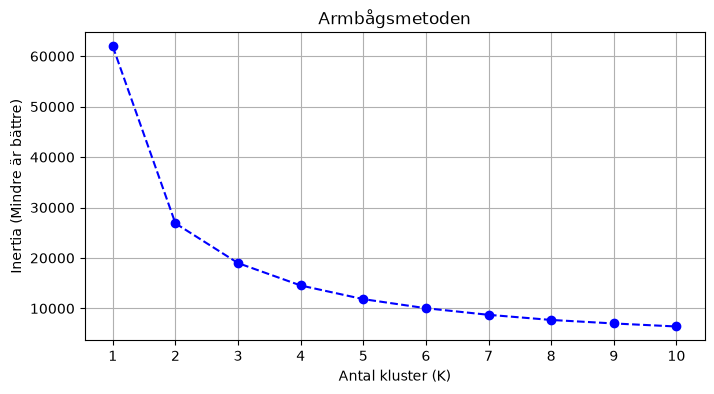

In [4]:
from sklearn.preprocessing import StandardScaler


df = pd.read_csv("./dataset/housing.csv") 
X = df.loc[:, ["median_income", "latitude", "longitude"]] 

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


inertia = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)


plt.figure(figsize=(8, 4))
plt.plot(k_values, inertia, marker='o', linestyle='--', color='b')
plt.title('Armbågsmetoden')
plt.xlabel('Antal kluster (K)')
plt.ylabel('Inertia (Mindre är bättre)')
plt.xticks(k_values)
plt.grid(True)
plt.show() 


När vi kollar datasetet med olika kluster och använder "armbågsmetoden" så ser vi att det optimala antal kluster ligger på 3-5 st. eftersom 4 ligger ganska mycket i mitten av "armbågen" så hade jag nog kört på den.

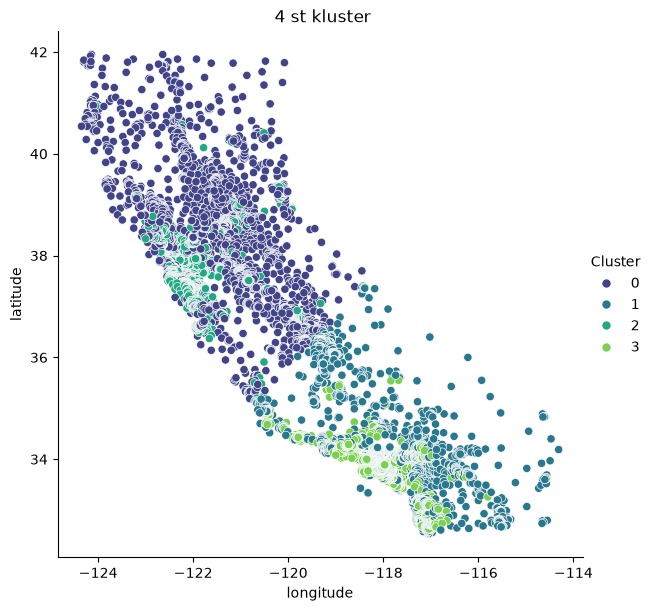

In [5]:
optimal_k = 4  
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)


X["Cluster"] = final_kmeans.fit_predict(X_scaled) 
X["Cluster"] = X["Cluster"].astype("category")

sns.relplot(
    x='longitude', 
    y='latitude', 
    hue='Cluster', 
    data=X, 
    height=6,
    palette='viridis' 
)
plt.title(f' {optimal_k} st kluster')
plt.show()

här har vi samma latitude vs langitude som vi hade innan fast med 4 kluster. Som vi kan se så ser det bättre updelat ut. speciellt om vi tänker på kluster 4 och 5 från den förra som var så pass små att man knappt kunde se dom på "kartan" 

med detta har vi generaliserat datan bättre och vi hade antagligen fått bättre predictions.

## Uppgift 8

In [6]:
df = pd.read_excel('./dataset/hr_employee_data.xlsx') #ladda in data
df.info() #kolla datan

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Emp_Id                 14999 non-null  str    
 1   satisfaction_level     14999 non-null  float64
 2   last_evaluation        14999 non-null  float64
 3   number_project         14999 non-null  int64  
 4   average_montly_hours   14999 non-null  int64  
 5   time_spend_company     14999 non-null  int64  
 6   Work_accident          14999 non-null  int64  
 7   left                   14999 non-null  int64  
 8   promotion_last_5years  14999 non-null  int64  
 9   Department             14999 non-null  str    
 10  salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(3)
memory usage: 1.5 MB


Jag satt och tänkte på hur man hade kunnat göra detta bra med tanke på allt vi redan gjort med det här datasetet. Jag kom fram till att jag skulle kolla hur nöjda/stressade personalen är på jobbet. Känner att jag inte gjorde inte deep dive på det innan så jag gör det nu. Tänker att det kan vara ganska relevant för både HR och högre chefer.

In [7]:
X = df[['satisfaction_level', 'last_evaluation', 'average_montly_hours', 'number_project']]

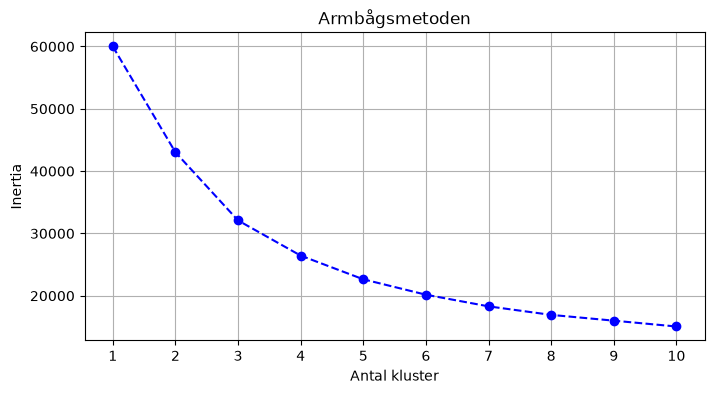

In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

inertia = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)


plt.figure(figsize=(8, 4))
plt.plot(k_values, inertia, marker='o', linestyle='--', color='b')
plt.title('Armbågsmetoden')
plt.xlabel('Antal kluster')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid(True)
plt.show() 

Genom att koll på armbågen så ser 4-5 kluster ut att vara mest optimalt. jag kommer att köra på 4 st då jag tycker att det känns mer som att det är i armbågens spets.

In [19]:
from sklearn.metrics import silhouette_score

kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_X3 = kmeans_3.fit_predict(X_scaled)

kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_X4 = kmeans_4.fit_predict(X_scaled)

s_score_x3 = silhouette_score(X_scaled, cluster_X3)
s_score_x4 = silhouette_score(X_scaled, cluster_X4)
print(f'silhouette score 3 st kluster: {s_score_x3:.3f}')
print(f'silhouette score 4st kluster: {s_score_x4:.3f}')

silhouette score 3 st kluster: 0.306
silhouette score 4st kluster: 0.288


bästa med silhouette_score jag hittade var 3. då det var den ända som hade över 0.3 och man vill ju komma så nära 1 som möjligt.

med detta i tanke så blir det. hur ska jag förhålla mig till detta. jag tänker att vi får tänka ur ett hr perspektiv och köra på 3 st. 

jobbar: lite, medel och mycket

In [20]:
df['Cluster'] = cluster_X3

cluster_df = df.groupby('Cluster')[['satisfaction_level', 'last_evaluation', 'average_montly_hours', 'number_project']].mean()

print(cluster_df)

         satisfaction_level  last_evaluation  average_montly_hours  \
Cluster                                                              
0                  0.762624         0.787944            215.800652   
1                  0.520525         0.559834            158.110268   
2                  0.182916         0.807198            248.570729   

         number_project  
Cluster                  
0              3.927916  
1              2.904489  
2              5.625680  


När jag kollar på average_montly_hours så kan jag se att den lägsta i genomsnitt jobbar nästan 160 timmar i månaden

och om vi kommar genomsnittet i sverige på en heltids anställning så har vi detta:

Arbetstimmar per månad (exempel för 2026)
- Januari: 160 timmar
- Februari: 160 timmar
- Mars: 176 timmar
- April: 160 timmar
- Maj: 152 timmar (färst timmar på grund av röda dagar)
- Juni: 168 timmar
- Juli: 184 timmar (flest timmar på grund av lång månad utan röda dagar)
- Augusti: 168 timmar
- September: 176 timmar
- Oktober: 176 timmar
- November: 168 timmar
- December: 160 timmar

Det innebär att vi kan har cluster 1 som våran "normala" arbetare. cluster 0 som dom som jobbar över lite, och cluster 2 som dom som jobbar över för mycket.

Hur en Hr hade kunnat kolla på dom här siffrorna:

In [28]:
columns_to_check = ['satisfaction_level', 'last_evaluation', 'average_montly_hours', 'number_project']
cluster_0_mean = df[df['Cluster'] == 0][columns_to_check].mean()

print(cluster_0_mean)

satisfaction_level        0.746167
last_evaluation           0.878657
average_montly_hours    213.507135
number_project            3.889682
dtype: float64


Kluster 0: jobbar ca 50 timmar mer i veckan än ett svenska genomsnitt. men dom är dock väldigt nöjda med jobbet nästan 75%. dom presterar även bra på jobbet.

In [30]:
columns_to_check = ['satisfaction_level', 'last_evaluation', 'average_montly_hours', 'number_project']
cluster_1_mean = df[df['Cluster'] == 1][columns_to_check].mean()

print(cluster_1_mean)

satisfaction_level        0.436653
last_evaluation           0.554448
average_montly_hours    149.395263
number_project            2.535835
dtype: float64


kluster 1: "medel svensson" dom jobbar lite mindre än en hel arbetsvecka och ganska genomsnittliga med hur dom presterar på jobbet och nöjda. Dessa är ju några man hade kunnat kolla på om man hade kunnat motivera dom på något sätt på jobbet eller prata med hur man hade kunnat höja trivslen på arbetsplatsen.

In [31]:
columns_to_check = ['satisfaction_level', 'last_evaluation', 'average_montly_hours', 'number_project']
cluster_2_mean = df[df['Cluster'] == 2][columns_to_check].mean()

print(cluster_2_mean)

satisfaction_level        0.172101
last_evaluation           0.811992
average_montly_hours    249.876005
number_project            5.685993
dtype: float64


kluster 2: Här har vi dom som är överarbetade på jobbet. dom jobbar på ca 2.4 fler project än övriga anstäldla (i genomsnitt) men dom presterar dock bra på arbetet. problemet är att dom är väldigt missnöjda på jobbet. Vi kan göra ett antagande att detta har med högarbetsbelastning att göra. Därför borde chefer och HR kolla på dom här anställda så att dom inte bli utbrända

## Uppgift 9

In [32]:
df = pd.read_csv('./dataset/1980sClassics.csv')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 998 entries, 0 to 997
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Track             998 non-null    str    
 1   Artist            998 non-null    str    
 2   Duration          998 non-null    str    
 3   Time_Signature    998 non-null    int64  
 4   Danceability      998 non-null    float64
 5   Energy            998 non-null    float64
 6   Key               998 non-null    int64  
 7   Loudness          998 non-null    float64
 8   Mode              998 non-null    int64  
 9   Speechiness       998 non-null    float64
 10  Acousticness      998 non-null    float64
 11  Instrumentalness  998 non-null    float64
 12  Liveness          998 non-null    float64
 13  Valence           998 non-null    float64
 14  Tempo             998 non-null    float64
 15  Popularity        998 non-null    int64  
 16  Year              998 non-null    int64  
dtypes: float

Min spontana tanke var att jag ville göra något med genres men såg att det inte fanns. lite tråkigt för hade varit kul att göra något med det och årtal

men vi har dock popularity så vi hade kunnat bryta ner vad dom gjorde en låt på 80talet populär

In [36]:
time_parts = df['Duration'].str.split(':', expand=True)

df['Duration_sec'] = time_parts[0].astype(int) * 60 + time_parts[1].astype(int)

df = df.drop('Duration', axis=1)

print(df[['Duration_sec']].head())

   Duration_sec
0           218
1           244
2           248
3           137
4           217


Eftersom duration var str får vi gör om det till något vi kan använda. vi gör det till sekunder

In [267]:
X = df[['Danceability', 'Key']]



scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

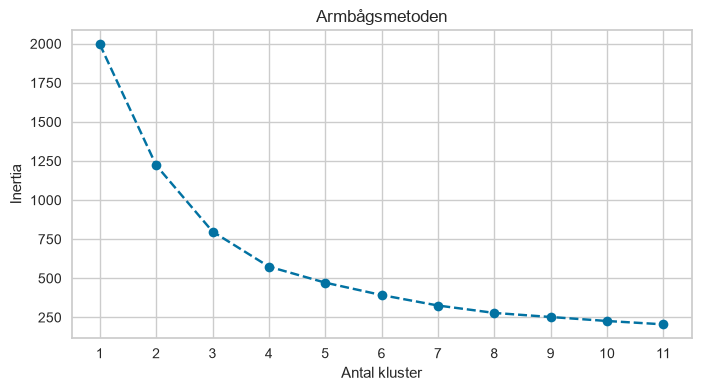

In [268]:
inertia = []
k_values = range(1, 12)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)


plt.figure(figsize=(8, 4))
plt.plot(k_values, inertia, marker='o', linestyle='--', color='b')
plt.title('Armbågsmetoden')
plt.xlabel('Antal kluster')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid(True)
plt.show() 

För k = 3 är genomsnittligt silhouette score: 0.382
För k = 4 är genomsnittligt silhouette score: 0.374
För k = 5 är genomsnittligt silhouette score: 0.364
För k = 6 är genomsnittligt silhouette score: 0.355


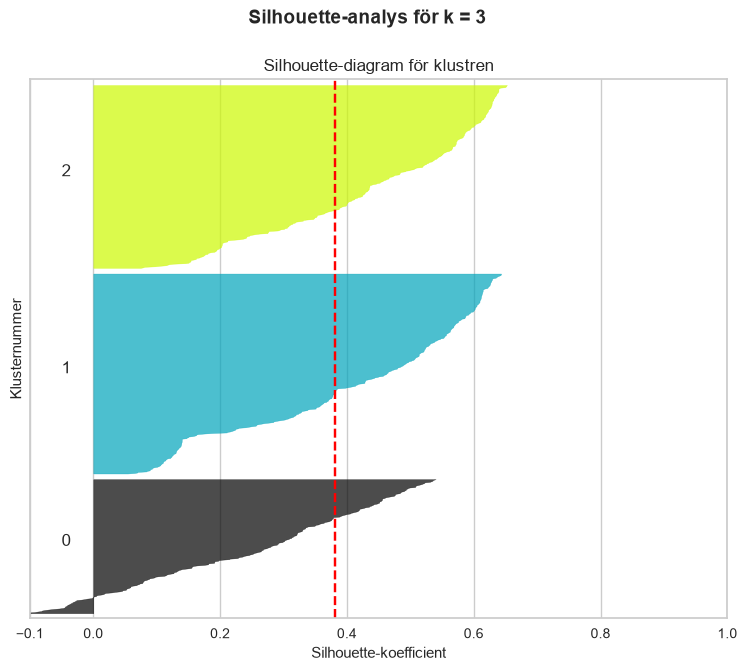

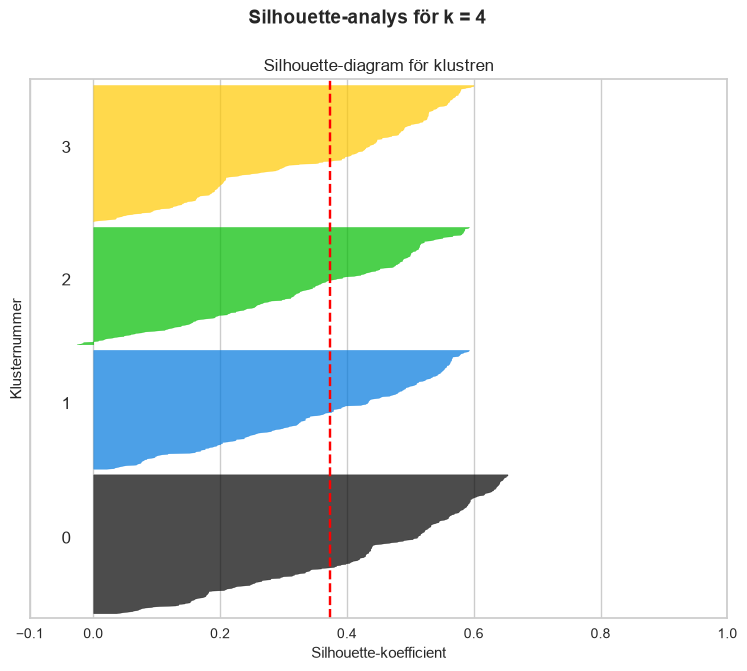

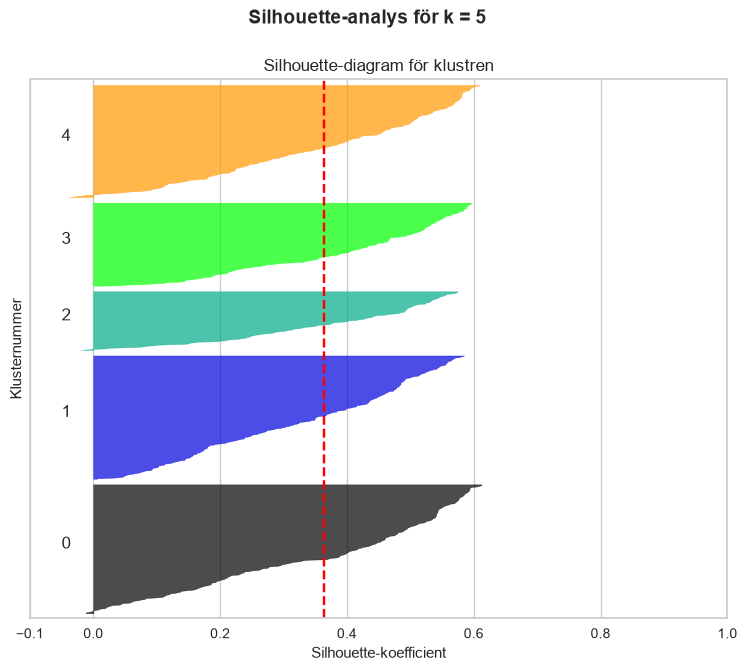

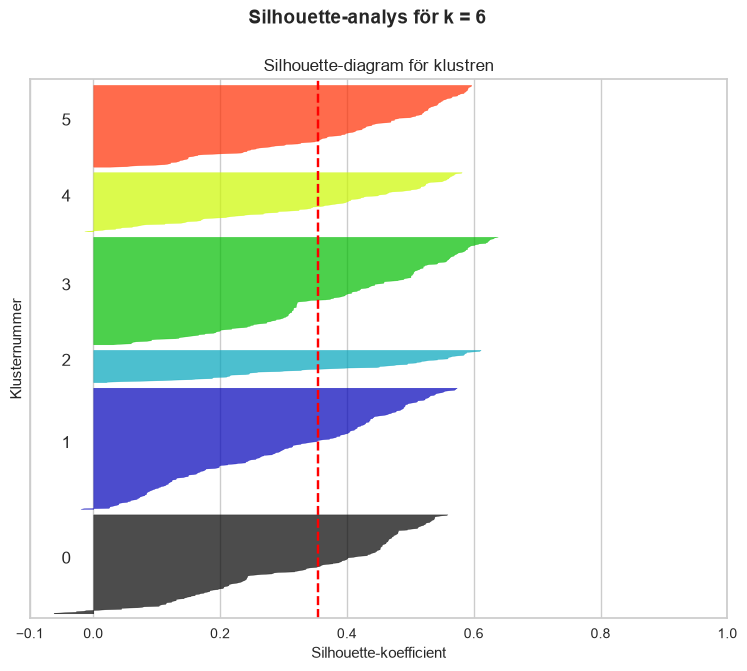

In [269]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

range_n_clusters = [3, 4, 5, 6]

for n_clusters in range_n_clusters:
    fig, ax1 = plt.subplots(1, 1)
    fig.set_size_inches(9, 7)

    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(X_scaled) + (n_clusters + 1) * 10])

    clusterer = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = clusterer.fit_predict(X_scaled)

    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    print(f"För k = {n_clusters} är genomsnittligt silhouette score: {silhouette_avg:.3f}")

    sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10 

    ax1.set_title("Silhouette-diagram för klustren")
    ax1.set_xlabel("Silhouette-koefficient")
    ax1.set_ylabel("Klusternummer")

    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.set_yticks([])
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    plt.suptitle(
        f"Silhouette-analys för k = {n_clusters}",
        fontsize=14,
        fontweight="bold",
    )

plt.show()

**Analys:**

---

försök **1** var dåligt.
körde på: 

X = df[['Popularity', 'Tempo', 'Key', 'Danceability', 'Duration_sec', 'Loudness']]

fick: 

För k = 3 är genomsnittligt silhouette score: 0.150
För k = 4 är genomsnittligt silhouette score: 0.142
För k = 5 är genomsnittligt silhouette score: 0.151
För k = 6 är genomsnittligt silhouette score: 0.152

---

försök **2** lite bättre

X = df[['Popularity', 'Tempo', 'Key', 'Duration_sec',]]

fick:

För k = 3 är genomsnittligt silhouette score: 0.212
För k = 4 är genomsnittligt silhouette score: 0.215
För k = 5 är genomsnittligt silhouette score: 0.220
För k = 6 är genomsnittligt silhouette score: 0.206

---

X = df[['Popularity', 'Speechiness', 'Energy', 'Acousticness']]


För k = 3 är genomsnittligt silhouette score: 0.354
För k = 4 är genomsnittligt silhouette score: 0.272
För k = 5 är genomsnittligt silhouette score: 0.258
För k = 6 är genomsnittligt silhouette score: 0.254


efter en massa försök så känner jag att jag måste tänka om... känner fick inte mycket mer än 0.3 om jag försökte clustra med populäritet. fick 0.5 om jag bara körde med populäritet och mode...



---

**Danceability**

X = df[['Danceability', 'Key']]
X = df[['Liveness','Danceability']]

Efter att ha testat runt med datasetet så är 

X = df[['Danceability', 'Key']]

typ det som ger snyggast silouette diagram.


Slutsats på detta:

Detta dataset var inte det bästa att göra klustring på. Hade man haft något tydligare att göra klustring på hade det kanske varit lättare att. många av värderna var väldig abstrakta. vilket gav "dåliga" värden.

jag känner väl att det som hade varit bäst att göra något på är väl Liveness/danceability.

Detta för att på så sätt veta om en låt är bra på att köra live om du har en 80tals kväll

In [270]:
X = df[['Danceability', 'Liveness']]



scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

För k = 4 är genomsnittligt silhouette score: 0.423


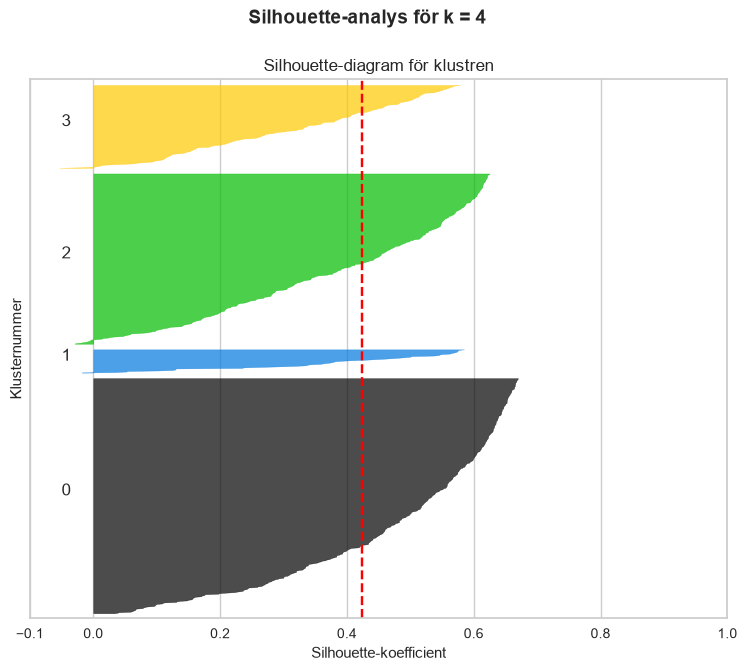

In [271]:
n_clusters = 4

fig, ax1 = plt.subplots(1, 1)
fig.set_size_inches(9, 7)

ax1.set_xlim([-0.1, 1])
ax1.set_ylim([0, len(X_scaled) + (n_clusters + 1) * 10])

# Träna modellen för k=4
clusterer = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = clusterer.fit_predict(X_scaled)

silhouette_avg = silhouette_score(X_scaled, cluster_labels)
print(f"För k = {n_clusters} är genomsnittligt silhouette score: {silhouette_avg:.3f}")

sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels)

y_lower = 10
for i in range(n_clusters):
    ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / n_clusters)
    ax1.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_silhouette_values,
        facecolor=color,
        edgecolor=color,
        alpha=0.7,
    )

    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10 

ax1.set_title("Silhouette-diagram för klustren")
ax1.set_xlabel("Silhouette-koefficient")
ax1.set_ylabel("Klusternummer")

ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
ax1.set_yticks([])
ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

plt.suptitle(
    f"Silhouette-analys för k = {n_clusters}",
    fontsize=14,
    fontweight="bold",
)

plt.show()

Då hade vi kunnat bryta ut detta till 4 kategorier:

- Hög Danceability + Låg Liveness: En låt som är dansvänlig men dom aldrig blev spelad live

- Låg Danceability + Låg Liveness: en låt som inte var dansvänlig och inte spelades live

- Hög Danceability + Hög Liveness: dansvänlig låt som ofta spelade live

- Låg Danceability + Hög Liveness: låtar som inte var dansvänlig men spelades ofta live


In [272]:
df['Cluster'] = cluster_labels

print("Antal låtar i varje kluster:")
print(df['Cluster'].value_counts().sort_index())

print("\nMedelvärden per kluster för att identifiera grupperna:")
print(df.groupby('Cluster')[['Danceability', 'Liveness']].mean())

Antal låtar i varje kluster:
Cluster
0    458
1     46
2    332
3    162
Name: count, dtype: int64

Medelvärden per kluster för att identifiera grupperna:
         Danceability  Liveness
Cluster                        
0            0.734980  0.096376
1            0.529783  0.742152
2            0.475428  0.141688
3            0.656685  0.326796


Med Detta kan vi namn ge kluster

- Hög Danceability + Låg Liveness: Cluster 0

- Låg Danceability + Låg Liveness: Cluster 2

- Hög Danceability + Hög Liveness: Cluster 3

- Låg Danceability + Hög Liveness: Cluster 1

Om vi kollar på hur många vi har i varje kluster så kan vi säga att "bra dans låter" som spelats live (cluster 3) är inte den största kategorin.

den största är Cluster 0. "bra dans låtar" som inte spelats live.

